In [1]:
import os, joblib, gc, numpy as np, pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# Konfigurasi Global
dataset_path = "/content/drive/MyDrive/Colab Notebooks"
def load_and_filter_data():
    print("Memuat dan memfilter data...")
    data = joblib.load(os.path.join(dataset_path, "dataset_split.joblib"))
    toxic = [
        'Pkt Len Var', 'Bwd IAT Mean', 'Down/Up Ratio', 'ACK Flag Cnt',
        'Bwd Pkt Len Min', 'Active Mean', 'Fwd Pkt Len Min', 'Pkt Len Min',
        'Fwd URG Flags', 'Active Min', 'Active Std', 'Active Max',
        'Idle Std', 'SYN Flag Cnt'
    ]
    feat_names = data['features']
    h_idx = [i for i, f in enumerate(feat_names) if f not in toxic]

    # Ambil data (X) dan Label (y)
    X_train = data['X_train'][:, h_idx].astype('float32')
    X_val   = data['X_val'][:, h_idx].astype('float32')
    X_test  = data['X_test'][:, h_idx].astype('float32')
    y_train, y_val, y_test = data['y_train'], data['y_val'], data['y_test']

    del data
    gc.collect()
    return X_train, X_val, X_test, y_train, y_val, y_test

X_train, X_val, X_test, y_train, y_val, y_test = load_and_filter_data()

X_train_benign = X_train[y_train == 0].astype('float32')
X_val_benign = X_val[y_val == 0].astype('float32')

print(f"Benign Train: {X_train_benign.shape[0]} | Benign Val: {X_val_benign.shape[0]}")

def prepare_ds(features, batch_size=2048):
    ds = tf.data.Dataset.from_tensor_slices((features, features))
    ds = ds.shuffle(buffer_size=20000)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = prepare_ds(X_train_benign)
val_ds = tf.data.Dataset.from_tensor_slices((X_val_benign, X_val_benign)).batch(2048).prefetch(tf.data.AUTOTUNE)

def build_autoencoder(input_dim):
    input_layer = layers.Input(shape=(input_dim,))

    # Encoder
    x = layers.Dense(32, activation='relu')(input_layer)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(16, activation='relu')(x)

    # Bottleneck
    bottleneck = layers.Dense(8, activation='relu', name="bottleneck")(x)

    # Decoder
    x = layers.Dense(16, activation='relu')(bottleneck)
    x = layers.Dense(32, activation='relu')(x)
    output_layer = layers.Dense(input_dim, activation='linear')(x)

    ae_model = models.Model(inputs=input_layer, outputs=output_layer, name="Autoencoder")
    encoder_model = models.Model(inputs=input_layer, outputs=bottleneck, name="Encoder")

    return ae_model, encoder_model

input_dim = X_train.shape[1]
ae, encoder = build_autoencoder(input_dim)

ae.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse')

early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-5)

print(f"Melatih Autoencoder pada {X_train_benign.shape[0]:,} baris data...")
history = ae.fit(
    train_ds,
    epochs=50,
    validation_data=val_ds,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

encoder.save(os.path.join(dataset_path, "ae_encoder_final.keras"))

Memuat dan memfilter data...
Benign Train: 9373163 | Benign Val: 2008535
Melatih Autoencoder pada 9,373,163 baris data...
Epoch 1/50
4577/4577 ━━━━━━━━━━━━━━━━━━━━ 89s 19ms/step - loss: 0.0085 - val_loss: 0.0030 - learning_rate: 0.0010
Epoch 2/50
4577/4577 ━━━━━━━━━━━━━━━━━━━━ 76s 17ms/step - loss: 0.0025 - val_loss: 0.0020 - learning_rate: 0.0010
Epoch 3/50
4577/4577 ━━━━━━━━━━━━━━━━━━━━ 83s 17ms/step - loss: 0.0020 - val_loss: 0.0017 - learning_rate: 0.0010
Epoch 4/50
4577/4577 ━━━━━━━━━━━━━━━━━━━━ 79s 17ms/step - loss: 0.0017 - val_loss: 0.0016 - learning_rate: 0.0010
Epoch 5/50
4577/4577 ━━━━━━━━━━━━━━━━━━━━ 81s 17ms/step - loss: 0.0015 - val_loss: 0.0014 - learning_rate: 0.0010
Epoch 6/50
4577/4577 ━━━━━━━━━━━━━━━━━━━━ 76s 17ms/step - loss: 0.0014 - val_loss: 0.0013 - learning_rate: 0.0010
Epoch 7/50
4577/4577 ━━━━━━━━━━━━━━━━━━━━ 83s 17ms/step - loss: 0.0013 - val_loss: 0.0012 - learning_rate: 0.0010
Epoch 8/50
4577/4577 ━━━━━━━━━━━━━━━━━━━━ 79s 17ms/step - loss: 0.0013 - val_los

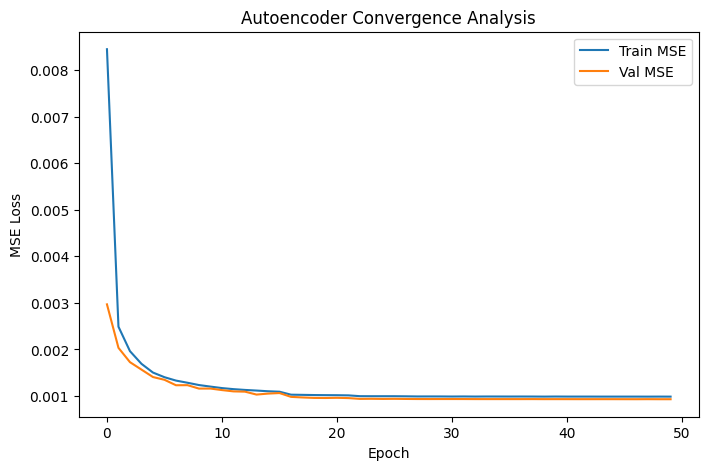

In [2]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train MSE')
plt.plot(history.history['val_loss'], label='Val MSE')
plt.title('Autoencoder Convergence Analysis')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

In [3]:
import gc

print("[INFO] Mengekstrak Fitur Laten (8 Dimensi)...")

Z_train = encoder.predict(X_train, batch_size=4096)
Z_val   = encoder.predict(X_val, batch_size=4096)
Z_test  = encoder.predict(X_test, batch_size=4096)

print(f"Hasil Ekstraksi: {Z_train.shape[1]} fitur laten siap digunakan.")

[INFO] Mengekstrak Fitur Laten (8 Dimensi)...
2758/2758 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step
591/591 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
591/591 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
Hasil Ekstraksi: 8 fitur laten siap digunakan.


In [4]:
import gc

if 'X_train' in locals(): del X_train
if 'X_val' in locals(): del X_val

gc.collect()

4562

In [5]:
from tensorflow.keras import layers, models, callbacks

def build_mlp_on_ae(input_dim=8):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),

        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),

        layers.Dense(1, activation='sigmoid')
    ], name="MLP_on_Standard_AE")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc', curve='PR')]
    )
    return model

mlp_ae = build_mlp_on_ae()
mlp_ae.summary()

Model: "MLP_on_Standard_AE"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,985 (39.00 KB)

 Trainable params: 9,729 (38.00 KB)

 Non-trainable params: 256 (1.00 KB)

In [7]:
class_weights = {0: 1.0, 1: 3.0}

early_stop = callbacks.EarlyStopping(
    monitor='val_auc',
    patience=5,
    restore_best_weights=True,
    mode='max'
)

print("Melatih MLP di atas fitur laten AE...")
history_mlp_ae = mlp_ae.fit(
    Z_train, y_train,
    validation_data=(Z_val, y_val),
    epochs=50,
    batch_size=4096,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

Melatih MLP di atas fitur laten AE...
Epoch 1/50
2758/2758 ━━━━━━━━━━━━━━━━━━━━ 77s 28ms/step - accuracy: 0.9823 - auc: 0.9676 - loss: 0.1400 - val_accuracy: 0.9857 - val_auc: 0.9719 - val_loss: 0.0656
Epoch 2/50
2758/2758 ━━━━━━━━━━━━━━━━━━━━ 77s 28ms/step - accuracy: 0.9835 - auc: 0.9692 - loss: 0.1337 - val_accuracy: 0.9848 - val_auc: 0.9734 - val_loss: 0.0652
Epoch 3/50
2758/2758 ━━━━━━━━━━━━━━━━━━━━ 78s 28ms/step - accuracy: 0.9840 - auc: 0.9701 - loss: 0.1306 - val_accuracy: 0.9851 - val_auc: 0.9716 - val_loss: 0.0671
Epoch 4/50
2758/2758 ━━━━━━━━━━━━━━━━━━━━ 77s 28ms/step - accuracy: 0.9841 - auc: 0.9705 - loss: 0.1295 - val_accuracy: 0.9858 - val_auc: 0.9730 - val_loss: 0.0657
Epoch 5/50
2758/2758 ━━━━━━━━━━━━━━━━━━━━ 83s 28ms/step - accuracy: 0.9844 - auc: 0.9709 - loss: 0.1280 - val_accuracy: 0.9868 - val_auc: 0.9737 - val_loss: 0.0635
Epoch 6/50
2758/2758 ━━━━━━━━━━━━━━━━━━━━ 80s 29ms/step - accuracy: 0.9847 - auc: 0.9713 - loss: 0.1267 - val_accuracy: 0.9867 - val_auc: 0.97

Melakukan evaluasi pada data Test...
591/591 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step

FINAL COMPARISON DATA: AE + MLP (8 DIM)
False Positive Rate (FPR) : 0.3688%
Detection Rate (Recall)   : 94.28%
F1-Score (Attack)         : 96.17%
--------------------------------------------------
              precision    recall  f1-score   support

      Normal     0.9884    0.9963    0.9923   2008536
      Attack     0.9813    0.9428    0.9617    412040

    accuracy                         0.9872   2420576
   macro avg     0.9848    0.9696    0.9770   2420576
weighted avg     0.9872    0.9872    0.9871   2420576



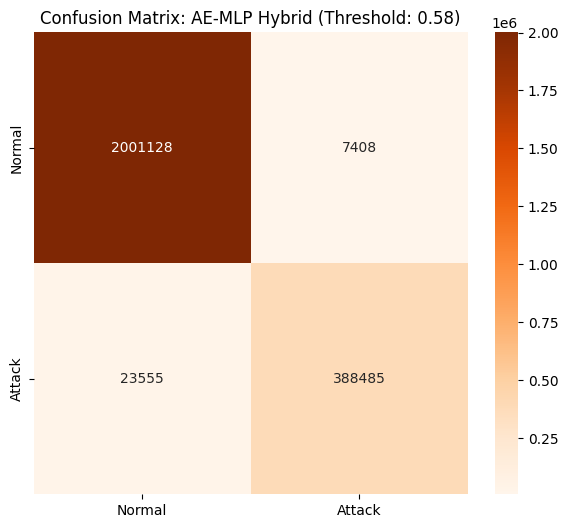

In [9]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score

print("Melakukan evaluasi pada data Test...")
y_probs_ae = mlp_ae.predict(Z_test, batch_size=4096).ravel()

t_final = 0.58
y_pred_ae = (y_probs_ae > t_final).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_ae).ravel()
fpr_ae = (fp / (fp + tn)) * 100
dr_ae = (tp / (tp + fn)) * 100

print("\n" + "="*50)
print("FINAL COMPARISON DATA: AE + MLP (8 DIM)")
print("="*50)
print(f"False Positive Rate (FPR) : {fpr_ae:.4f}%")
print(f"Detection Rate (Recall)   : {dr_ae:.2f}%")
print(f"F1-Score (Attack)         : {f1_score(y_test, y_pred_ae)*100:.2f}%")
print("-" * 50)
print(classification_report(y_test, y_pred_ae, target_names=['Normal', 'Attack'], digits=4))
print("="*50)

plt.figure(figsize=(7, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_ae), annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
plt.title(f'Confusion Matrix: AE-MLP Hybrid (Threshold: {t_final})')
plt.show()

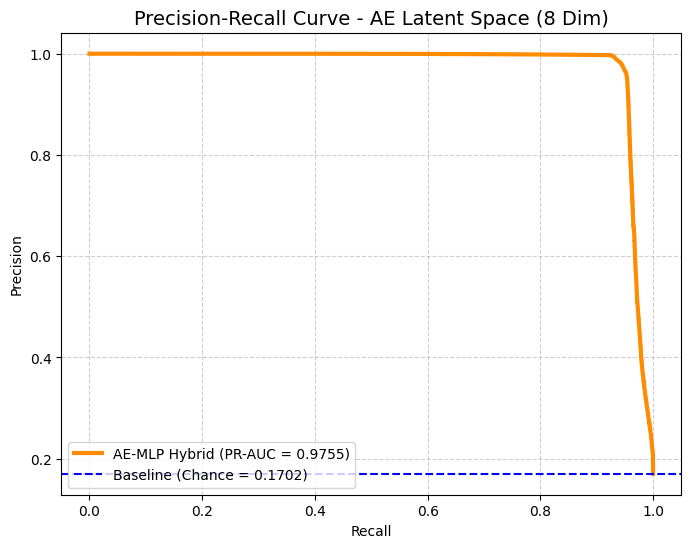

AE Latent PR-AUC: 0.9755


In [11]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

precision_ae, recall_ae, _ = precision_recall_curve(y_test, y_probs_ae)
pr_auc_ae = auc(recall_ae, precision_ae)

plt.figure(figsize=(8, 6))
plt.plot(recall_ae, precision_ae, label=f'AE-MLP Hybrid (PR-AUC = {pr_auc_ae:.4f})', color='darkorange', lw=3)

baseline = len(y_test[y_test==1]) / len(y_test)
plt.axhline(y=baseline, color='blue', linestyle='--', label=f'Baseline (Chance = {baseline:.4f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - AE Latent Space (8 Dim)', fontsize=14)
plt.legend(loc="lower left")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f"AE Latent PR-AUC: {pr_auc_ae:.4f}")

In [12]:
def predict_ae_live(data_point):

    input_data = data_point.reshape(1, -1).astype('float32')
    z_latent = encoder.predict(input_data, verbose=0)
    prob = mlp_ae.predict(z_latent, verbose=0)[0][0]
    threshold = 0.5800
    if prob >= threshold:
        label = "ATTACK"
        confidence = prob
    else:
        label = "BENIGN"
        confidence = 1 - prob

    return label, confidence

idx = 100
test_data = X_test[idx]
hasil_ae, skor_ae = predict_ae_live(test_data)

label_asli = "Attack" if y_test[idx] == 1 else "Benign"

print(f"--- UJI COBA TEST DATA KE-{idx} (MODEL AE-MLP) ---")
print(f"Label Asli      : {label_asli}")
print(f"Hasil AI AE     : {hasil_ae}")
print(f"Tingkat Yakin   : {skor_ae*100:.2f}%")

--- UJI COBA TEST DATA KE-100 (MODEL AE-MLP) ---
Label Asli      : Attack
Hasil AI AE     : ATTACK
Tingkat Yakin   : 99.88%


In [13]:
from sklearn.ensemble import IsolationForest
import numpy as np
import pandas as pd

print("Melatih Isolation Forest pada fitur laten Benign (AE)...")
Z_benign_train = Z_train[y_train == 0]

iso_ae = IsolationForest(
    n_estimators=100,
    contamination=0.01,
    random_state=42,
    n_jobs=-1
)
iso_ae.fit(Z_benign_train)
print("Isolation Forest di Ruang Laten AE siap!")

def zero_day_detector_ae(latent_data_point):
    prob = mlp_ae.predict(latent_data_point.reshape(1, -1), verbose=0)[0][0]
    ae_label = "ATTACK" if prob >= 0.5800 else "BENIGN"

    is_normal = iso_ae.predict(latent_data_point.reshape(1, -1))[0]

    status = "Aman"
    if ae_label == "BENIGN" and is_normal == -1:
        status = "POTENSI ZERO-DAY (Anomaly Detected)"
    elif ae_label == "ATTACK":
        status = "SERANGAN TERDETEKSI (Known Attack)"
    else:
        status = "TRAFIK NORMAL"

    return status, prob, is_normal

idx = 100
hasil_sim, p_score_sim, anomaly_score_sim = zero_day_detector_ae(Z_test[idx])

print(f"\n--- HASIL ANALISIS DATA KE-{idx} (MODEL AE) ---")
print(f"Status Akhir   : {hasil_sim}")
print(f"MLP Prob       : {p_score_sim:.4f}")
print(f"Anomaly Laten  : {'Outlier (Aneh)' if anomaly_score_sim == -1 else 'Normal'}")

print("\nMenyisir celah keamanan pada AE-MLP Hybrid...")

y_pred_ae_idx = (y_probs_ae > 0.5800).astype(int)
missed_by_ae = np.where((y_test == 1) & (y_pred_ae_idx == 0))[0]

print(f"Total serangan yang lolos dari MLP AE: {len(missed_by_ae):,} data.")

if len(missed_by_ae) > 0:
    print("Mengecek kemampuan deteksi anomali di ruang laten 8-dimensi...")
    saved_count = 0
    sample_saved = []

    for idx in missed_by_ae:
        is_normal = iso_ae.predict(Z_test[idx].reshape(1, -1))[0]
        if is_normal == -1:
            saved_count += 1
            if len(sample_saved) < 5:
                sample_saved.append({
                    'Index': idx,
                    'MLP_Prob': f"{y_probs_ae[idx]:.4f}",
                    'Anomaly': 'Outlier',
                    'Actual': 'ATTACK'
                })

    rescue_rate = (saved_count / len(missed_by_ae)) * 100
    print(f"HASIL AKHIR: Dari {len(missed_by_ae):,} serangan lolos, {saved_count:,} BERHASIL DIDETEKSI sebagai ANOMALI!")
    print(f"Rescue Rate AE: {rescue_rate:.2f}%")

    if sample_saved:
        print("\n--- TABEL SAMPEL SERANGAN TERSELAMATKAN ---")
        print(pd.DataFrame(sample_saved).to_string(index=False))
else:
    print("AE-MLP tidak meloloskan serangan apapun.")

Melatih Isolation Forest pada fitur laten Benign (AE)...
Isolation Forest di Ruang Laten AE siap!

--- HASIL ANALISIS DATA KE-100 (MODEL AE) ---
Status Akhir   : SERANGAN TERDETEKSI (Known Attack)
MLP Prob       : 0.9988
Anomaly Laten  : Normal

Menyisir celah keamanan pada AE-MLP Hybrid...
Total serangan yang lolos dari MLP AE: 23,555 data.
Mengecek kemampuan deteksi anomali di ruang laten 8-dimensi...
HASIL AKHIR: Dari 23,555 serangan lolos, 360 BERHASIL DIDETEKSI sebagai ANOMALI!
Rescue Rate AE: 1.53%

--- TABEL SAMPEL SERANGAN TERSELAMATKAN ---
 Index MLP_Prob Anomaly Actual
   216   0.0602 Outlier ATTACK
 17415   0.0662 Outlier ATTACK
 24265   0.0470 Outlier ATTACK
 42866   0.0642 Outlier ATTACK
 63438   0.0482 Outlier ATTACK
